In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch Version:", torch.__version__)

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Device:", device)


PyTorch Version: 2.11.0+cu128
Device: cuda


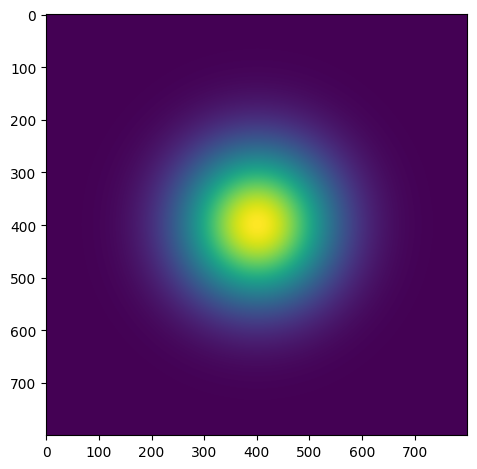

In [ ]:
X, Y = np.mgrid[-4.0:4:0.01, -4.0:4:0.01]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)

gaussian = torch.exp(-(x**2 + y**2) / 2.0)

plt.imshow(gaussian.cpu().numpy())
plt.tight_layout()
plt.show()

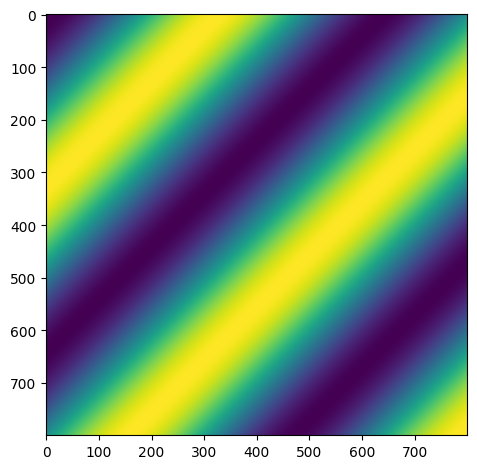

In [ ]:
sine = torch.sin(x + y)
plt.imshow(sine.cpu().numpy())
plt.tight_layout()
plt.show()

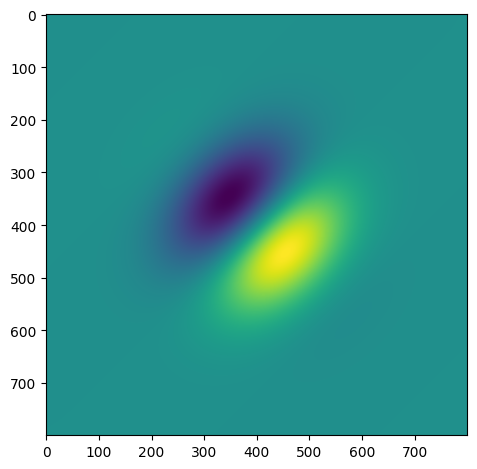

In [ ]:
gabor = gaussian * sine

plt.imshow(gabor.cpu().numpy())
plt.tight_layout()
plt.show()

In [ ]:
Y, X = np.mgrid[-1.3:1.3:0.005, -2:1:0.005]
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z)
for i in range(200):
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = zs_

/tmp/ipykernel_1303/348124730.py:14: ComplexWarning: Casting complex values to real discards the imaginary part
  img = np.uint8(np.clip(img, 0, 255))


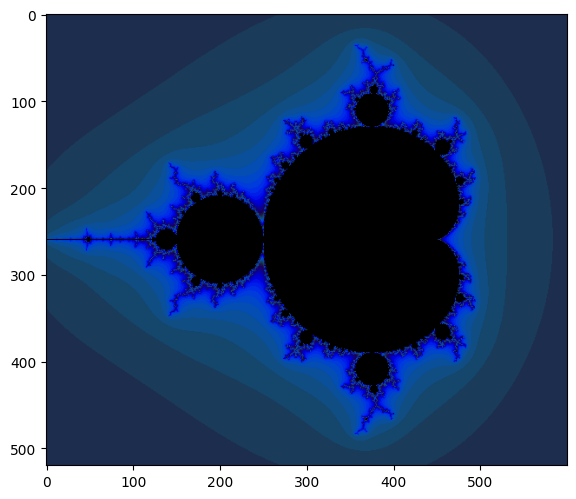

In [ ]:
def processFractal(a):


    a_cyclic = (6.28 * a / 20.0).reshape(list(a.shape) + [1])

    img = np.concatenate([
        10 + 20 * np.cos(a_cyclic),
        30 + 50 * np.sin(a_cyclic),
        155 - 80 * np.cos(a_cyclic)
    ], 2)

    img[a == a.max()] = 0

    img = np.uint8(np.clip(img, 0, 255))

    return img

    fig = plt.figure(figsize=(16, 10))

plt.imshow(
    processFractal(ns.cpu().numpy())
)

plt.tight_layout(pad=0)
plt.show()


Device: cuda


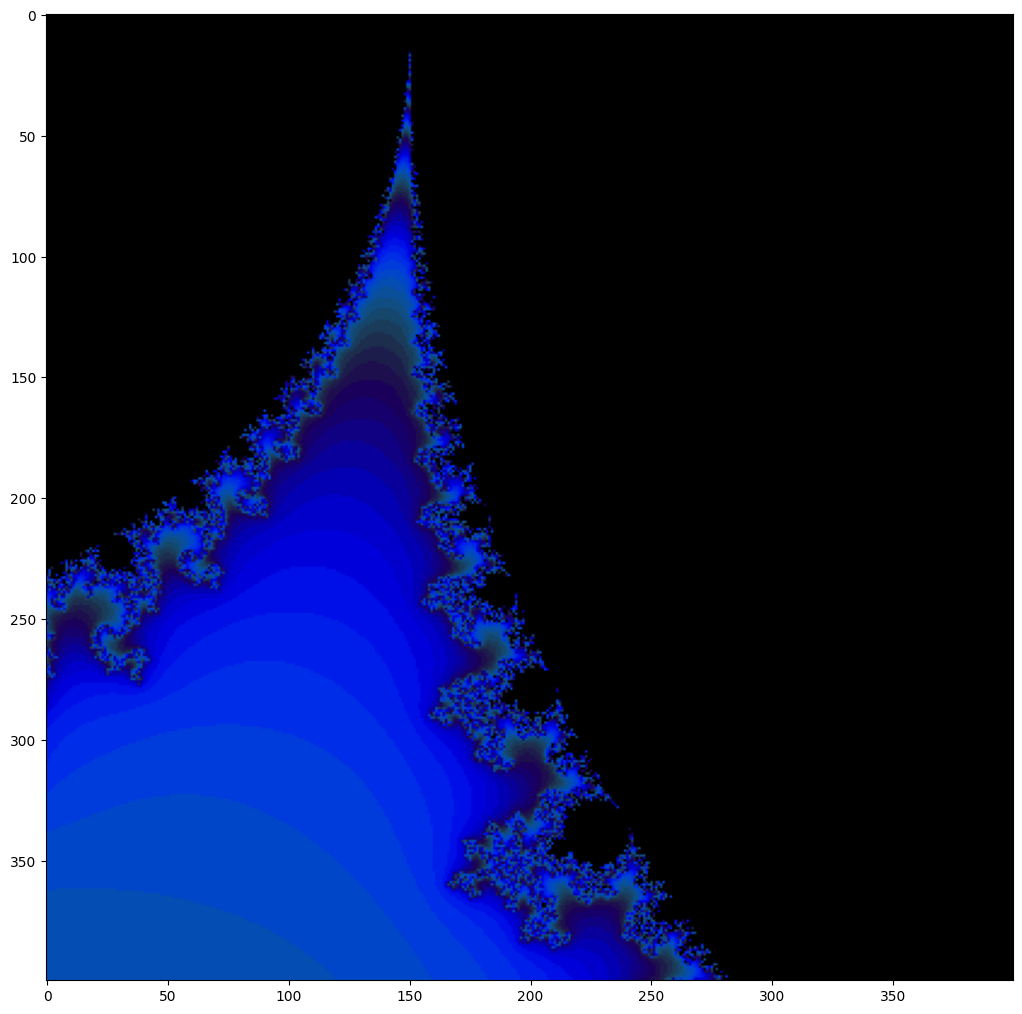

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 选择 GPU / CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Device:", device)


# =========================
# 1. 建立 zoom 后的高分辨率坐标
# =========================

Y, X = np.mgrid[
    0.0:0.4:0.001,
    -0.9:-0.5:0.001
]


# =========================
# 2. 转成 PyTorch Tensor
# =========================

x = torch.Tensor(X)
y = torch.Tensor(Y)

# 每一个像素变成一个复数
z = torch.complex(x, y)

# zs 是不断迭代变化的值
zs = z.clone()

# ns 用来记录每一个点撑了多少轮
# 这里直接使用实数 Tensor，避免之前的 ComplexWarning
ns = torch.zeros(z.shape)


# =========================
# 3. 放到 GPU / CPU
# =========================

z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)


# =========================
# 4. Mandelbrot 迭代
# =========================

for i in range(200):

    # z_new = z_old^2 + c
    zs_ = zs * zs + z

    # 判断有没有发散
    not_diverged = torch.abs(zs_) < 4.0

    # 这一轮还没发散就 +1
    ns += not_diverged

    # 新值成为下一轮的旧值
    zs = zs_


# =========================
# 5. 给 fractal 上色
# =========================

def processFractal(a):

    a_cyclic = (6.28 * a / 20.0).reshape(
        list(a.shape) + [1]
    )

    img = np.concatenate([
        10 + 20 * np.cos(a_cyclic),
        30 + 50 * np.sin(a_cyclic),
        155 - 80 * np.cos(a_cyclic)
    ], 2)

    # 200轮都没有发散的区域设成黑色
    img[a == a.max()] = 0

    img = np.uint8(
        np.clip(img, 0, 255)
    )

    return img


# =========================
# 6. 显示结果
# =========================

plt.figure(figsize=(10, 10))

plt.imshow(
    processFractal(ns.cpu().numpy())
)

plt.tight_layout(pad=0)
plt.show()

Device: cuda


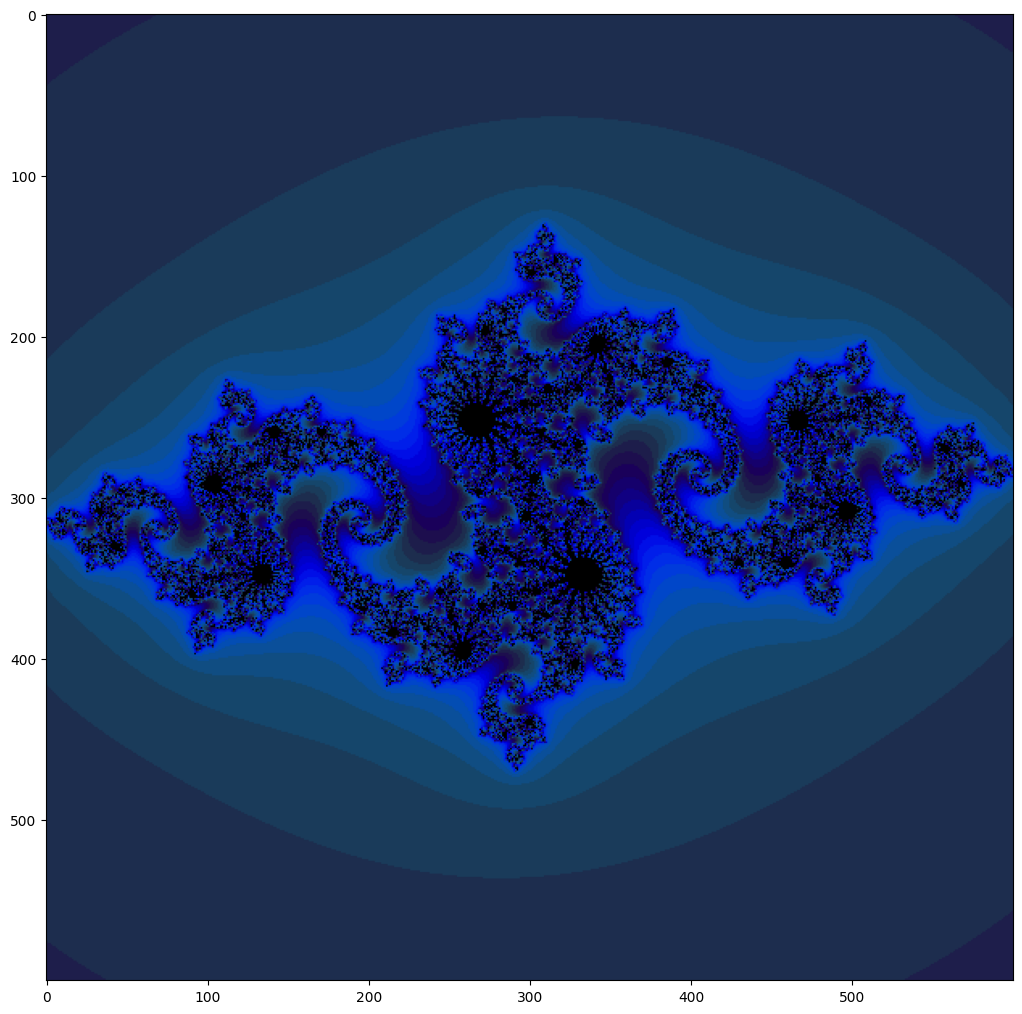

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 选择 GPU / CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Device:", device)


# 1. 建立复平面坐标
Y, X = np.mgrid[
    -1.5:1.5:0.005,
    -1.5:1.5:0.005
]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)


# 2. 每一个像素作为不同的初始 z0
zs = torch.complex(x, y)


# 3. Julia set 的 c 是固定的
c = torch.tensor(
    -0.8 + 0.156j,
    dtype=torch.complex64,
    device=device
)


# 4. 计数器
ns = torch.zeros(zs.shape, device=device)


# 5. 进行 200 次迭代
for i in range(200):

    # z_new = z_old^2 + c
    zs_ = zs * zs + c

    # 判断这一轮是否还没有发散
    not_diverged = torch.abs(zs_) < 4.0

    # 没发散就 +1
    ns += not_diverged

    # 新 z 留给下一轮
    zs = zs_


# 6. 上色函数
def processFractal(a):

    a_cyclic = (6.28 * a / 20.0).reshape(
        list(a.shape) + [1]
    )

    img = np.concatenate([
        10 + 20 * np.cos(a_cyclic),
        30 + 50 * np.sin(a_cyclic),
        155 - 80 * np.cos(a_cyclic)
    ], 2)

    img[a == a.max()] = 0

    img = np.uint8(
        np.clip(img, 0, 255)
    )

    return img


# 7. 显示 Julia set
plt.figure(figsize=(10, 10))

plt.imshow(
    processFractal(ns.cpu().numpy())
)

plt.tight_layout(pad=0)
plt.show()

In [ ]:
A = torch.tensor([0.0, 0.0], device=device)
B = torch.tensor([3.0, 0.0], device=device)

direction = B - A

P = A + direction / 3
Q = A + 2 * direction / 3

print("A =", A)
print("B =", B)
print("Direction =", direction)
print("P =", P)
print("Q =", Q)

A = tensor([0., 0.], device='cuda:0')
B = tensor([3., 0.], device='cuda:0')
Direction = tensor([3., 0.], device='cuda:0')
P = tensor([1., 0.], device='cuda:0')
Q = tensor([2., 0.], device='cuda:0')


In [ ]:
segment = Q - P

print("Segment =", segment)

Segment = tensor([1., 0.], device='cuda:0')


In [ ]:
angle = torch.tensor(torch.pi / 3, device=device)

print("Angle =", angle)
print("cos(60°) =", torch.cos(angle))
print("sin(60°) =", torch.sin(angle))

Angle = tensor(1.0472, device='cuda:0')
cos(60°) = tensor(0.5000, device='cuda:0')
sin(60°) = tensor(0.8660, device='cuda:0')


In [ ]:
rotated_x = segment[0] * torch.cos(angle) - segment[1] * torch.sin(angle)
rotated_y = segment[0] * torch.sin(angle) + segment[1] * torch.cos(angle)

print("Rotated x =", rotated_x)
print("Rotated y =", rotated_y)

Rotated x = tensor(0.5000, device='cuda:0')
Rotated y = tensor(0.8660, device='cuda:0')


In [ ]:
rotated = torch.stack([rotated_x, rotated_y])

print("Rotated =", rotated)
R = P + rotated

print("R =", R)

Rotated = tensor([0.5000, 0.8660], device='cuda:0')
R = tensor([1.5000, 0.8660], device='cuda:0')


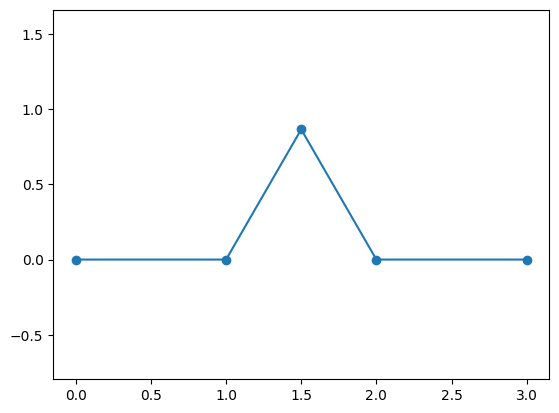

In [ ]:
points = torch.stack([A, P, R, Q, B])

points_cpu = points.cpu().numpy()

plt.plot(points_cpu[:, 0], points_cpu[:, 1], marker='o')
plt.axis('equal')
plt.show()

In [ ]:
starts = torch.stack([A, P, R, Q])

print("Starts:")
print(starts)
ends = torch.stack([P, R, Q, B])

print("Ends:")
print(ends)
directions = ends - starts

print("Directions:")
print(directions)

Starts:
tensor([[0.0000, 0.0000],
        [1.0000, 0.0000],
        [1.5000, 0.8660],
        [2.0000, 0.0000]], device='cuda:0')
Ends:
tensor([[1.0000, 0.0000],
        [1.5000, 0.8660],
        [2.0000, 0.0000],
        [3.0000, 0.0000]], device='cuda:0')
Directions:
tensor([[ 1.0000,  0.0000],
        [ 0.5000,  0.8660],
        [ 0.5000, -0.8660],
        [ 1.0000,  0.0000]], device='cuda:0')


In [ ]:
P_all = starts + directions / 3
Q_all = starts + 2 * directions / 3

print("P points:")
print(P_all)

print("Q points:")
print(Q_all)

P points:
tensor([[0.3333, 0.0000],
        [1.1667, 0.2887],
        [1.6667, 0.5774],
        [2.3333, 0.0000]], device='cuda:0')
Q points:
tensor([[0.6667, 0.0000],
        [1.3333, 0.5774],
        [1.8333, 0.2887],
        [2.6667, 0.0000]], device='cuda:0')


In [ ]:
small_directions = directions / 3

print("Small directions:")
print(small_directions)
x = small_directions[:, 0]
y = small_directions[:, 1]
rotated_x_all = x * torch.cos(angle) - y * torch.sin(angle)
rotated_y_all = x * torch.sin(angle) + y * torch.cos(angle)
rotated_all = torch.stack(
    [rotated_x_all, rotated_y_all],
    dim=1
)

print("Rotated directions:")
print(rotated_all)
R_all = P_all + rotated_all

print("R points:")
print(R_all)

Small directions:
tensor([[ 0.3333,  0.0000],
        [ 0.1667,  0.2887],
        [ 0.1667, -0.2887],
        [ 0.3333,  0.0000]], device='cuda:0')
Rotated directions:
tensor([[ 1.6667e-01,  2.8868e-01],
        [-1.6667e-01,  2.8868e-01],
        [ 3.3333e-01,  1.4901e-08],
        [ 1.6667e-01,  2.8868e-01]], device='cuda:0')
R points:
tensor([[0.5000, 0.2887],
        [1.0000, 0.5774],
        [2.0000, 0.5774],
        [2.5000, 0.2887]], device='cuda:0')


In [ ]:
new_starts = torch.stack(
    [starts, P_all, R_all, Q_all],
    dim=1
)

print("New starts shape:", new_starts.shape)
new_ends = torch.stack(
    [P_all, R_all, Q_all, ends],
    dim=1
)

print("New ends shape:", new_ends.shape)
new_starts = new_starts.reshape(-1, 2)
new_ends = new_ends.reshape(-1, 2)

print("New starts:", new_starts.shape)
print("New ends:", new_ends.shape)
starts = new_starts
ends = new_ends

New starts shape: torch.Size([4, 4, 2])
New ends shape: torch.Size([4, 4, 2])
New starts: torch.Size([16, 2])
New ends: torch.Size([16, 2])


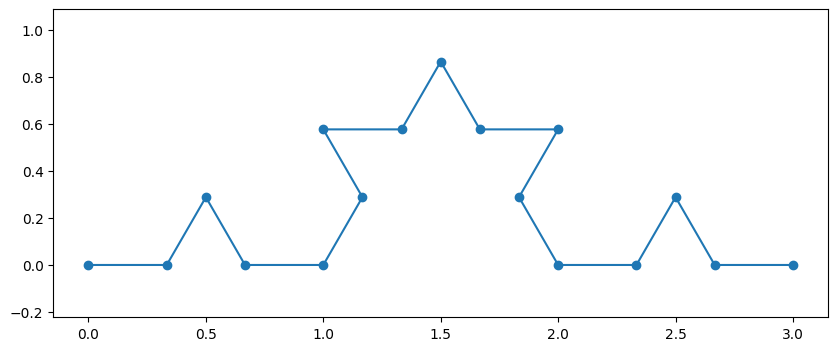

In [ ]:
path = torch.cat([starts, ends[-1:]], dim=0)

path_cpu = path.cpu().numpy()

plt.figure(figsize=(10, 4))
plt.plot(path_cpu[:, 0], path_cpu[:, 1], marker='o')
plt.axis('equal')
plt.show()

In [ ]:
def koch_step(starts, ends, angle_deg=60.0):
    # Direction of all current line segments
    directions = ends - starts

    # 1/3 and 2/3 points
    P = starts + directions / 3
    Q = starts + 2 * directions / 3

    # New Koch segments have 1/3 of the old direction
    small_directions = directions / 3

    x = small_directions[:, 0]
    y = small_directions[:, 1]

    # Convert angle from degrees to radians
    angle = torch.deg2rad(
        torch.tensor(
            angle_deg,
            device=starts.device,
            dtype=starts.dtype
        )
    )

    # Rotate all small direction vectors together
    rotated_x = x * torch.cos(angle) - y * torch.sin(angle)
    rotated_y = x * torch.sin(angle) + y * torch.cos(angle)

    rotated = torch.stack(
        [rotated_x, rotated_y],
        dim=1
    )

    # Peak point
    R = P + rotated

    # Each old segment becomes:
    # start -> P
    # P -> R
    # R -> Q
    # Q -> end

    new_starts = torch.stack(
        [starts, P, R, Q],
        dim=1
    )

    new_ends = torch.stack(
        [P, R, Q, ends],
        dim=1
    )

    # [N, 4, 2] -> [4N, 2]
    new_starts = new_starts.reshape(-1, 2)
    new_ends = new_ends.reshape(-1, 2)

    return new_starts, new_ends

In [ ]:
starts = torch.tensor(
    [[0.0, 0.0]],
    device=device
)

ends = torch.tensor(
    [[3.0, 0.0]],
    device=device
)

In [ ]:
iterations = 5

for i in range(iterations):
    starts, ends = koch_step(starts, ends)

    print(
        f"Iteration {i + 1}: "
        f"{starts.shape[0]} segments"
    )

Iteration 1: 4 segments
Iteration 2: 16 segments
Iteration 3: 64 segments
Iteration 4: 256 segments
Iteration 5: 1024 segments


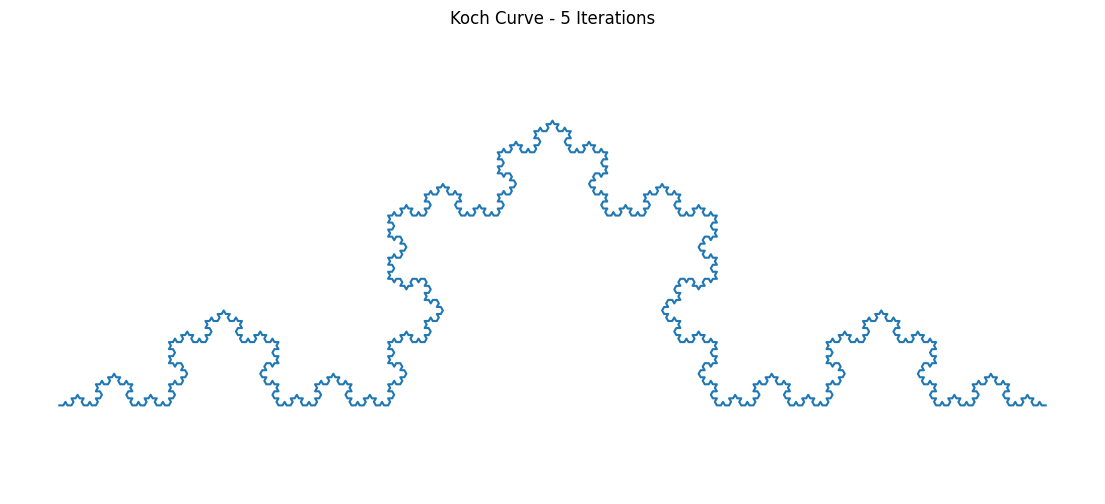

In [ ]:
path = torch.cat(
    [starts, ends[-1:]],
    dim=0
)

path_cpu = path.cpu().numpy()

plt.figure(figsize=(14, 6))

plt.plot(
    path_cpu[:, 0],
    path_cpu[:, 1]
)

plt.axis("equal")
plt.axis("off")
plt.title(
    f"Koch Curve - {iterations} Iterations"
)

plt.show()

Koch Curve Analysis

Each segment is replaced by 4 new segments,
each scaled by a factor of 1/3.

Number of segments:
Iteration 0: 1
Iteration 1: 4
Iteration 2: 16
Iteration 3: 64
Iteration 4: 256
Iteration 5: 1024

The Koch curve is self-similar because each part is
a scaled copy of the whole curve.

Its self-similarity dimension is:

D = log(4) / log(3) ≈ 1.2619